<h1>01 - EDA

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = Path("../data/sp500_stocks.csv")
df = pd.read_csv(DATA_PATH)
df.head()

,Date,Close,High,Low,Open,Volume,Ticker
0,2005-01-03,0.946491,0.973708,0.936171,0.968773,691992000,AAPL
1,2005-01-04,0.956211,0.979092,0.941705,0.953968,1096810400,AAPL
2,2005-01-05,0.964586,0.975802,0.957856,0.963987,680433600,AAPL
3,2005-01-06,0.965334,0.970717,0.947089,0.967128,705555200,AAPL
4,2005-01-07,1.035620,1.041304,0.968324,0.972062,2227450400,AAPL


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 259073 entries, 0 to 259072
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Date    259073 non-null  str    
 1   Close   259073 non-null  float64
 2   High    259073 non-null  float64
 3   Low     259073 non-null  float64
 4   Open    259073 non-null  float64
 5   Volume  259073 non-null  int64  
 6   Ticker  259073 non-null  str    
dtypes: float64(4), int64(1), str(2)
memory usage: 17.1 MB


In [4]:
df.describe()

,Close,High,Low,Open,Volume
count,259073.000000,259073.000000,259073.000000,259073.000000,2.590730e+05
mean,90.211950,91.082372,89.296486,90.201343,4.146036e+07
std,117.784960,118.888997,116.612774,117.769350,1.241613e+08
min,0.129000,0.131714,0.127286,0.130000,1.380000e+04
25%,26.686663,26.990343,26.379522,26.696936,4.152000e+06
50%,48.892555,49.353313,48.381375,48.884915,9.455600e+06
75%,107.133034,108.150002,106.159142,107.145506,2.507055e+07
max,1183.470093,1200.544223,1159.271081,1184.857644,3.692928e+09


In [5]:
print("Dataframe contains " + str(df.shape[0]) + " rows across " + str(df.shape[1]) + " columns")

Dataframe contains 259073 rows across 7 columns


In [6]:
print("Dataframe contains records from " + str(df['Date'].min()) + " to " + str(df['Date'].max()))
df['Date'] = pd.to_datetime(df['Date']).dt.date

Dataframe contains records from 2005-01-03 to 2025-12-30


<h3>Daily Log Returns

In [7]:
#log returns
df['LogReturn'] = np.log(df['Close']/df['Close'].shift(1))
df.head()

,Date,Close,High,Low,Open,Volume,Ticker,LogReturn
0,2005-01-03,0.946491,0.973708,0.936171,0.968773,691992000,AAPL,NaN
1,2005-01-04,0.956211,0.979092,0.941705,0.953968,1096810400,AAPL,0.010218
2,2005-01-05,0.964586,0.975802,0.957856,0.963987,680433600,AAPL,0.008720
3,2005-01-06,0.965334,0.970717,0.947089,0.967128,705555200,AAPL,0.000775
4,2005-01-07,1.035620,1.041304,0.968324,0.972062,2227450400,AAPL,0.070282


Why log returns instead of simple returns?<br>
1. log returns are additive
2. log returns are symmetric

In [8]:
(df[['Open', 'High', 'Low', 'Close', 'Volume']] == 0).sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

<h3>Missing Data Report

In [9]:
import pandas_market_calendars as mcal

nyse = mcal.get_calendar('NYSE')
overall_end = df['Date'].max()

def audit_ticker(group):
    ticker_start, ticker_end = group['Date'].min(), group['Date'].max()
    expected = nyse.schedule(ticker_start, ticker_end).index
    missing = expected.difference(group['Date'])

    return pd.Series({
        'first_date': ticker_start,
        'last_date': ticker_end,
        'missing_days': len(missing),
        'missing_pct': round(len(missing) / len(expected) * 100, 2),
        'likely_delisted': ticker_end < overall_end - pd.Timedelta(days=10),
        'multi_day_halts': (missing.to_series().diff() == pd.Timedelta(days=1)).sum()
    })

report = df.groupby('Ticker').apply(audit_ticker, include_groups=False)
print(report.sort_values('missing_days', ascending=False))

        first_date   last_date  missing_days  missing_pct  likely_delisted  \
Ticker                                                                       
AAPL    2005-01-03  2025-12-30             0          0.0            False   
ABBV    2013-01-02  2025-12-30             0          0.0            False   
AMT     2005-01-03  2025-12-30             0          0.0            False   
AMZN    2005-01-03  2025-12-30             0          0.0            False   
APD     2005-01-03  2025-12-30             0          0.0            False   
AVGO    2009-08-06  2025-12-30             0          0.0            False   
AXP     2005-01-03  2025-12-30             0          0.0            False   
BA      2005-01-03  2025-12-30             0          0.0            False   
BAC     2005-01-03  2025-12-30             0          0.0            False   
BLK     2005-01-03  2025-12-30             0          0.0            False   
C       2005-01-03  2025-12-30             0          0.0       

How to handle missing trading days?

<h3>Summary Statistics per Stock

In [10]:
def compute_stats(group):
    returns = group['LogReturn'].dropna()

    #sharpe ratio
    ann_return = returns.mean() * 252
    ann_volatility = returns.std() * np.sqrt(252)
    sharpe = ann_return / ann_volatility #assuming risk_free_rate=0

    #max drawdown
    cumulative = np.exp(returns.cumsum())
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()

    return pd.Series({
        'annualized_return': ann_return,
        'annualized_return_pct': (np.exp(ann_return) - 1) * 100,
        'annualized_volatility': ann_volatility,
        'sharpe_ratio': sharpe,
        'max_drawdown_pct': max_drawdown * 100
    })

stats = df.groupby('Ticker').apply(compute_stats, include_groups=False)
ranked = stats.sort_values('sharpe_ratio', ascending=False)

print("=== Top 10 by Sharpe Ratio ===")
print(ranked.head(10))

print("\n=== Bottom 10 by Sharpe Ratio ===")
print(ranked.tail(10))


=== Top 10 by Sharpe Ratio ===
        annualized_return  annualized_return_pct  annualized_volatility  \
Ticker                                                                    
AAPL             0.270183              31.020365               0.321588   
ABBV             0.173095              18.897947               0.268089   
LIN              0.114324              12.111483               0.254161   
CAT              0.129367              13.810801               0.323259   
GS               0.132331              14.148577               0.352625   
SPY              0.080266               8.357538               0.214361   
BLK              0.116713              12.379714               0.363662   
LLY              0.111172              11.758738               0.374798   
COST             0.086235               9.006250               0.393792   
GE               0.056509               5.813624               0.329291   

        sharpe_ratio  max_drawdown_pct  
Ticker                     

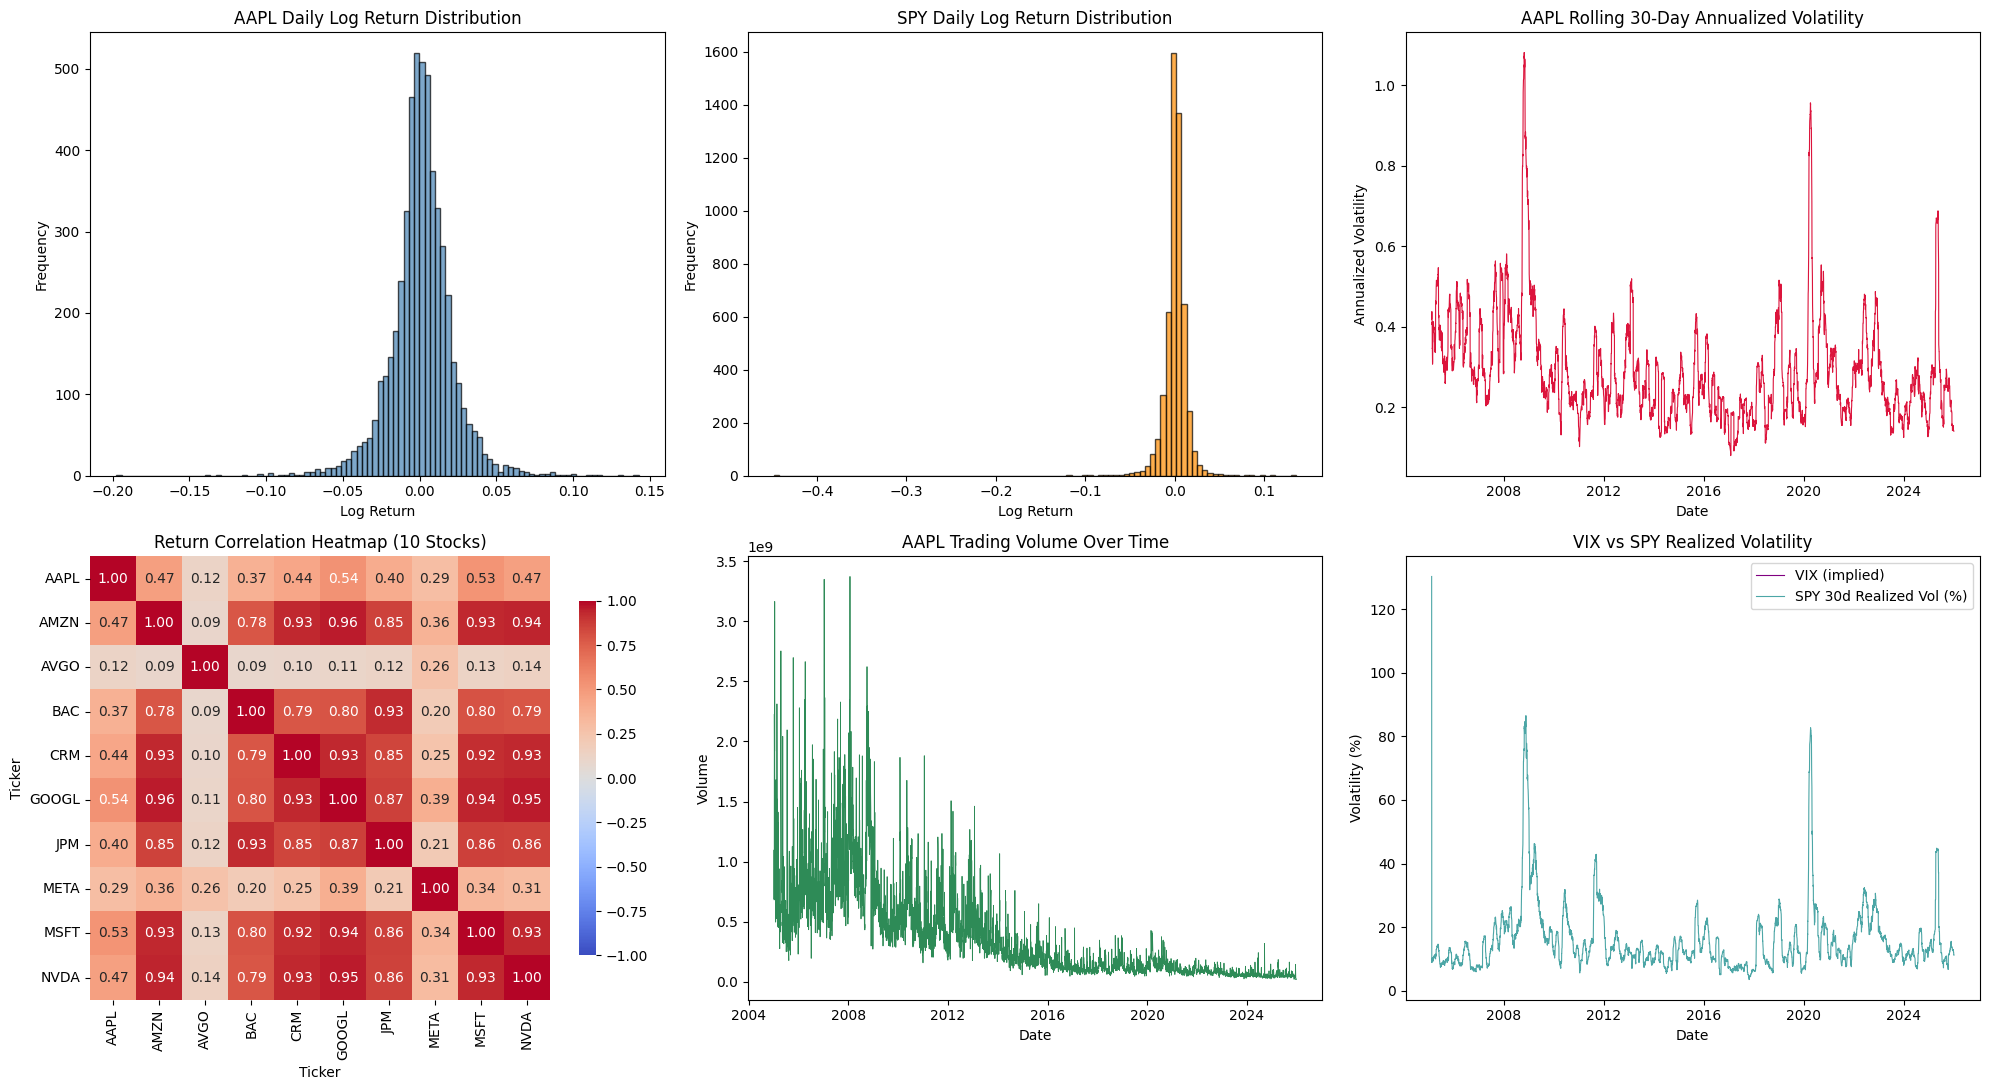

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# 1. Daily returns distribution — AAPL
aapl_returns = df[df['Ticker'] == 'AAPL']['LogReturn'].dropna()
axes[0, 0].hist(aapl_returns, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('AAPL Daily Log Return Distribution')
axes[0, 0].set_xlabel('Log Return')
axes[0, 0].set_ylabel('Frequency')

# 2. Daily returns distribution — SPY
spy_returns = df[df['Ticker'] == 'SPY']['LogReturn'].dropna()
axes[0, 1].hist(spy_returns, bins=100, color='darkorange', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('SPY Daily Log Return Distribution')
axes[0, 1].set_xlabel('Log Return')
axes[0, 1].set_ylabel('Frequency')

# 3. Rolling 30-day volatility — AAPL
aapl = df[df['Ticker'] == 'AAPL'].set_index('Date')
rolling_vol_30d = aapl['LogReturn'].rolling(30, min_periods=30).std() * np.sqrt(252)
axes[0, 2].plot(rolling_vol_30d.index, rolling_vol_30d, color='crimson', linewidth=0.8)
axes[0, 2].set_title('AAPL Rolling 30-Day Annualized Volatility')
axes[0, 2].set_xlabel('Date')
axes[0, 2].set_ylabel('Annualized Volatility')

# 4. Correlation heatmap — 10 selected stocks
selected_tickers = df['Ticker'].unique()[:10]  # or hand-pick 10 tickers of interest
pivot = df[df['Ticker'].isin(selected_tickers)].pivot(index='Date', columns='Ticker', values='LogReturn')
corr = pivot.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1, 0],
            cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1)
axes[1, 0].set_title('Return Correlation Heatmap (10 Stocks)')

# 5. Volume trends
# Aggregate a few tickers or show one representative stock's volume over time
aapl_volume = df[df['Ticker'] == 'AAPL'].set_index('Date')['Volume']
axes[1, 1].plot(aapl_volume.index, aapl_volume, color='seagreen', linewidth=0.6)
axes[1, 1].set_title('AAPL Trading Volume Over Time')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Volume')

# 6. VIX vs realized volatility
vix = df[df['Ticker'] == '^VIX'].set_index('Date')['Close']
spy_realized_vol = df[df['Ticker'] == 'SPY'].set_index('Date')['LogReturn'].rolling(30).std() * np.sqrt(252) * 100
axes[1, 2].plot(vix.index, vix, label='VIX (implied)', color='purple', linewidth=0.8)
axes[1, 2].plot(spy_realized_vol.index, spy_realized_vol, label='SPY 30d Realized Vol (%)', color='teal', linewidth=0.8, alpha=0.7)
axes[1, 2].set_title('VIX vs SPY Realized Volatility')
axes[1, 2].set_xlabel('Date')
axes[1, 2].set_ylabel('Volatility (%)')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

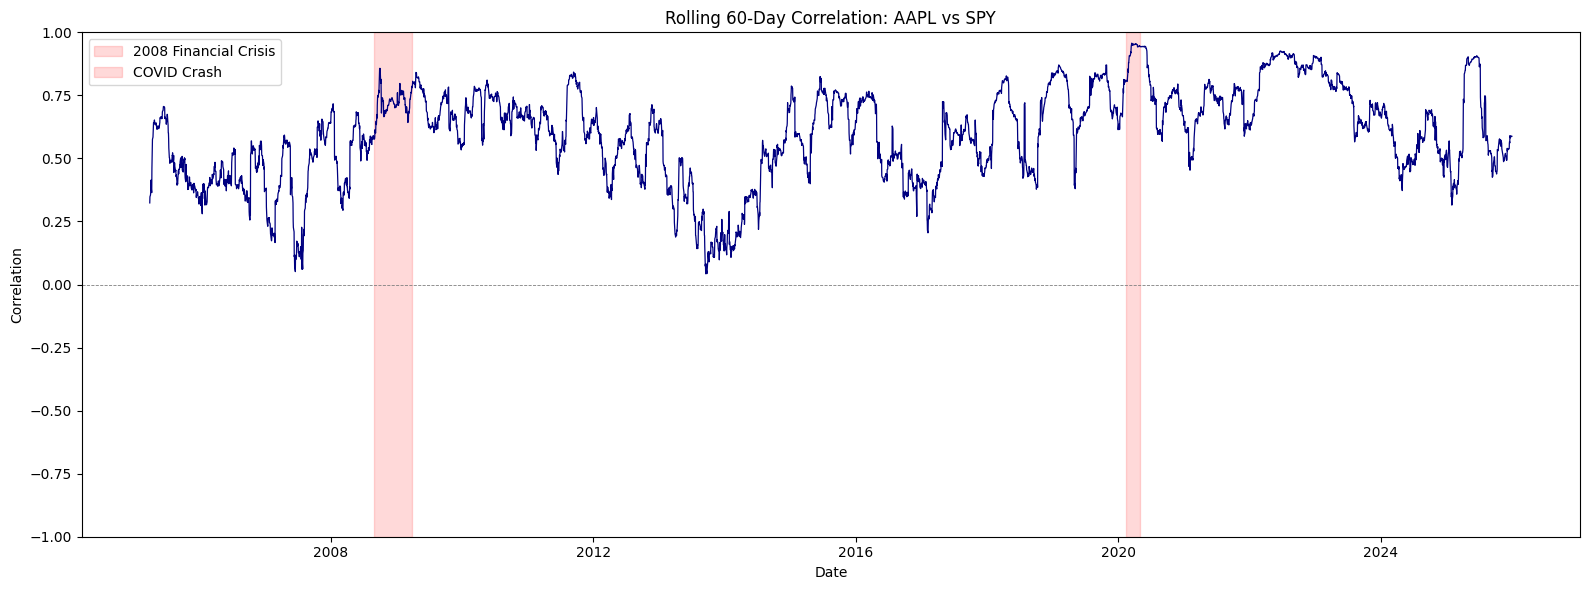

In [12]:
# Pivot to get AAPL and SPY log returns aligned by date
pair = df[df['Ticker'].isin(['AAPL', 'SPY'])].pivot(index='Date', columns='Ticker', values='LogReturn')

# Rolling 60-day correlation
rolling_corr = pair['AAPL'].rolling(60).corr(pair['SPY'])

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(rolling_corr.index, rolling_corr, color='navy', linewidth=0.9)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.6)
ax.set_title('Rolling 60-Day Correlation: AAPL vs SPY')
ax.set_xlabel('Date')
ax.set_ylabel('Correlation')
ax.set_ylim(-1, 1)

# Optionally shade known crash periods for visual reference
crash_periods = {
    '2008 Financial Crisis': ('2008-09-01', '2009-03-31'),
    'COVID Crash': ('2020-02-15', '2020-04-30'),
}
for label, (start, end) in crash_periods.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color='red', alpha=0.15, label=label)

ax.legend()
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


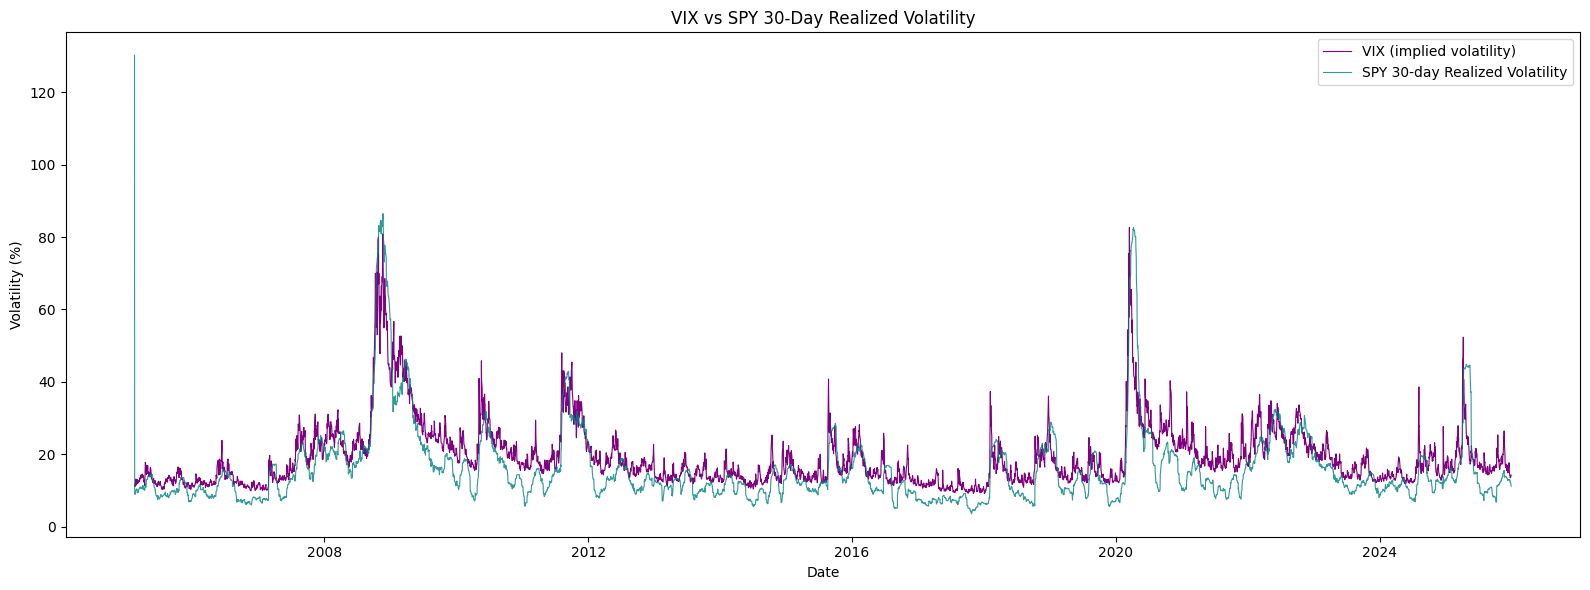

Correlation (contemporaneous): 0.858


In [13]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

# 1. Download VIX data
vix_data = yf.download('^VIX', start=df['Date'].min(), end=df['Date'].max())
vix_close = vix_data['Close']
if isinstance(vix_close, pd.DataFrame):  # yfinance sometimes returns multi-index columns
    vix_close = vix_close.iloc[:, 0]

# 2. SPY 30-day realized volatility (annualized, in percentage terms to match VIX's scale)
spy = df[df['Ticker'] == 'SPY'].set_index('Date')
spy_realized_vol = spy['LogReturn'].rolling(30).std() * np.sqrt(252) * 100

# 3. Align both series on shared dates
aligned = pd.DataFrame({
    'VIX': vix_close,
    'SPY_Realized_Vol_30d': spy_realized_vol
}).dropna()

# 4. Plot
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(aligned.index, aligned['VIX'], label='VIX (implied volatility)', color='purple', linewidth=0.8)
ax.plot(aligned.index, aligned['SPY_Realized_Vol_30d'], label='SPY 30-day Realized Volatility', color='teal', linewidth=0.8, alpha=0.8)
ax.set_title('VIX vs SPY 30-Day Realized Volatility')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility (%)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Correlation (contemporaneous): {aligned['VIX'].corr(aligned['SPY_Realized_Vol_30d']):.3f}")